In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_style("whitegrid")

In [5]:
# Load the Spotify songs dataset
spotify_df = pd.read_csv("spotify_songs.csv")
spotify_df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6.0,-2.634,1.0,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754.0
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11.0,-4.969,1.0,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600.0
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1.0,-3.432,0.0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616.0
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7.0,-3.778,1.0,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093.0
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1.0,-4.672,1.0,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052.0


In [6]:
# Explore the basic structure of the dataset
print(f"Number of Rows    : {spotify_df.shape[0]}")
print(f"Number of Columns : {spotify_df.shape[1]}")
display(spotify_df.info())
display(spotify_df.describe())
display(spotify_df.describe(include="object"))

Number of Rows    : 21886
Number of Columns : 23
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21886 entries, 0 to 21885
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  21886 non-null  object 
 1   track_name                21881 non-null  object 
 2   track_artist              21881 non-null  object 
 3   track_popularity          21886 non-null  int64  
 4   track_album_id            21886 non-null  object 
 5   track_album_name          21881 non-null  object 
 6   track_album_release_date  21886 non-null  object 
 7   playlist_name             21886 non-null  object 
 8   playlist_id               21885 non-null  object 
 9   playlist_genre            21885 non-null  object 
 10  playlist_subgenre         21885 non-null  object 
 11  danceability              21885 non-null  float64
 12  energy                    21885 non-null  float64
 13  key         

None

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,21886.000000,21885.000000,21885.000000,21885.000000,21885.00000,21885.000000,21885.000000,21885.000000,21885.000000,21885.000000,21885.000000,21885.000000,21885.000000
mean,45.282738,0.651683,0.694234,5.377153,-6.79935,0.586749,0.110974,0.181461,0.059907,0.187385,0.535385,121.147404,223624.097875
std,24.785271,0.151606,0.175275,3.628626,3.02259,0.492428,0.106499,0.217296,0.190507,0.151257,0.227707,28.658199,56990.339581
min,0.000000,0.000000,0.000175,0.000000,-46.44800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,29.000000,0.552000,0.583000,2.000000,-8.18600,0.000000,0.040000,0.019200,0.000000,0.093100,0.361000,97.910000,188453.000000
50%,49.000000,0.672000,0.715000,6.000000,-6.21100,1.000000,0.062700,0.093000,0.000006,0.126000,0.539000,119.969000,216000.000000
75%,65.000000,0.764000,0.830000,9.000000,-4.73400,1.000000,0.141000,0.266000,0.001450,0.241000,0.714000,139.785000,250987.000000
max,100.000000,0.979000,1.000000,11.000000,1.27500,1.000000,0.877000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


,track_id,track_name,track_artist,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,playlist_subgenre
count,21886,21881,21881,21886,21881,21886,21886,21885,21885,21885
unique,19374,16558,7656,15348,13880,3781,308,325,5,17
top,7BKLCZ1jbUBVqRi2FVlTVw,Alive,Queen,5L1xcowSxwzFUSJzvyMp48,Greatest Hits,2010-01-01,Indie Poptimism,4JkkvMpVl4lSioqQjeAL0q,rap,southern hip hop
freq,8,13,136,42,115,175,308,194,5746,1675


In [7]:
# Check missing values and duplicate records
missing_values = spotify_df.isnull().sum()
display(missing_values[missing_values > 0].sort_values(ascending=False))
print(f"\nDuplicate Rows : {spotify_df.duplicated().sum()}")

# Separate numerical and categorical columns
numerical_columns = spotify_df.select_dtypes(include=np.number).columns
categorical_columns = spotify_df.select_dtypes(include="object").columns
print("\nNumerical Columns:\n")
print(numerical_columns)
print("\nCategorical Columns:\n")
print(categorical_columns)

,0
track_name,5
track_artist,5
track_album_name,5
playlist_id,1
playlist_genre,1
playlist_subgenre,1
danceability,1
energy,1
key,1
loudness,1



Duplicate Rows : 0

Numerical Columns:

Index(['track_popularity', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms'],
      dtype='object')

Categorical Columns:

Index(['track_id', 'track_name', 'track_artist', 'track_album_id',
       'track_album_name', 'track_album_release_date', 'playlist_name',
       'playlist_id', 'playlist_genre', 'playlist_subgenre'],
      dtype='object')


In [8]:
# Remove rows with missing values
spotify_df = spotify_df.dropna()
print(f"Dataset Shape After Removing Missing Values : {spotify_df.shape}")

Dataset Shape After Removing Missing Values : (21880, 23)


In [9]:
# Select the audio features for K-Means clustering
clustering_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms"
]
spotify_cluster_df = spotify_df[clustering_features]
display(spotify_cluster_df.head())

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,0.748,0.916,-2.634,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754.0
1,0.726,0.815,-4.969,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600.0
2,0.675,0.931,-3.432,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616.0
3,0.718,0.930,-3.778,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093.0
4,0.650,0.833,-4.672,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052.0


In [10]:
# Standardize the selected features
scaler = StandardScaler()
spotify_scaled = scaler.fit_transform(spotify_cluster_df)
spotify_scaled = pd.DataFrame(spotify_scaled, columns=clustering_features)
spotify_scaled.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,0.635278,1.265376,1.377984,-0.494444,-0.365789,-0.314507,-0.807179,-0.076337,0.030873,-0.506476
1,0.490172,0.689147,0.605529,-0.691649,-0.502001,-0.292410,1.121454,0.692187,-0.739036,-1.070659
2,0.153790,1.350954,1.113993,-0.345132,-0.469789,-0.314385,-0.511636,0.340862,0.099685,-0.824730
3,0.437406,1.345249,0.999531,-0.084071,-0.703099,-0.314457,0.109864,-1.134704,0.028082,-0.956731
4,-0.011104,0.791841,0.703782,-0.704796,-0.465647,-0.314507,-0.688168,0.832717,0.098569,-0.606525


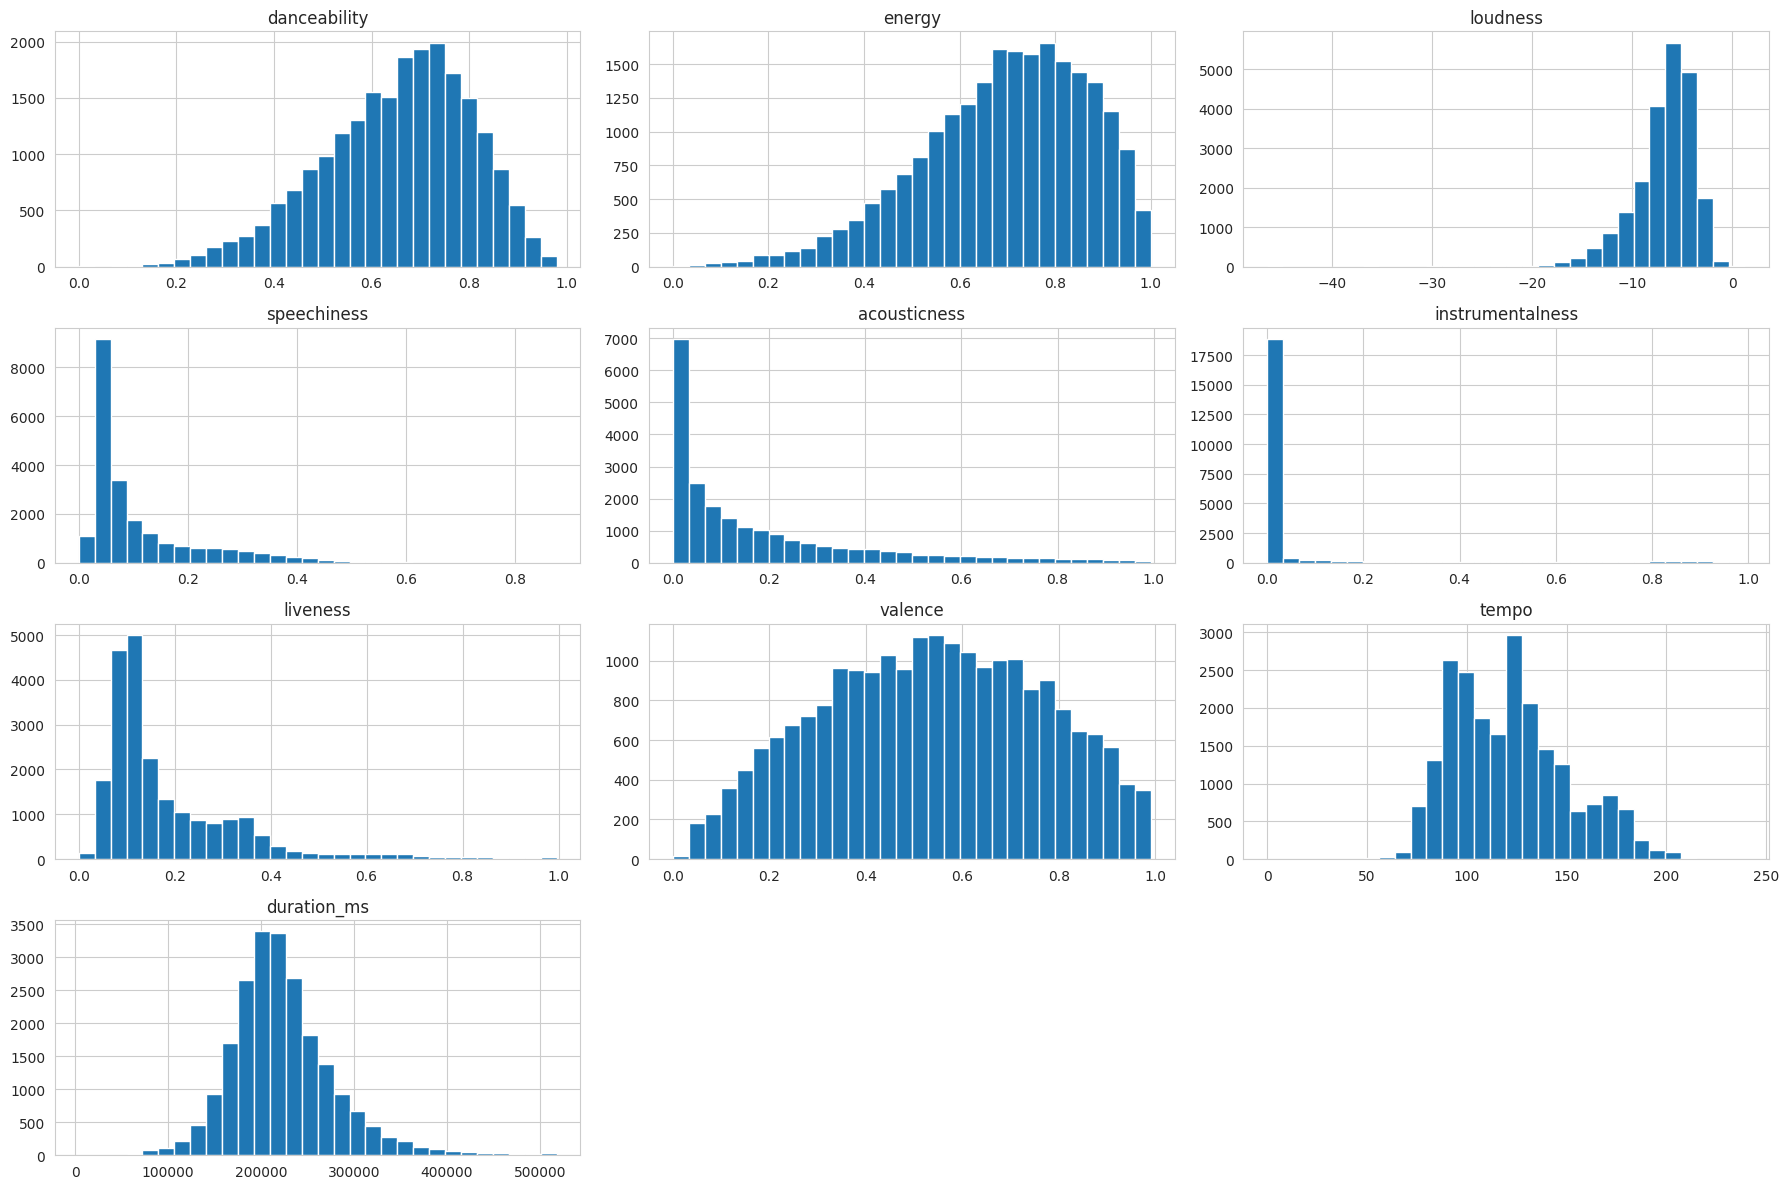

In [11]:
# Visualize the distribution of numerical features
spotify_cluster_df.hist(figsize=(18, 12), bins=30)
plt.tight_layout()
plt.show()

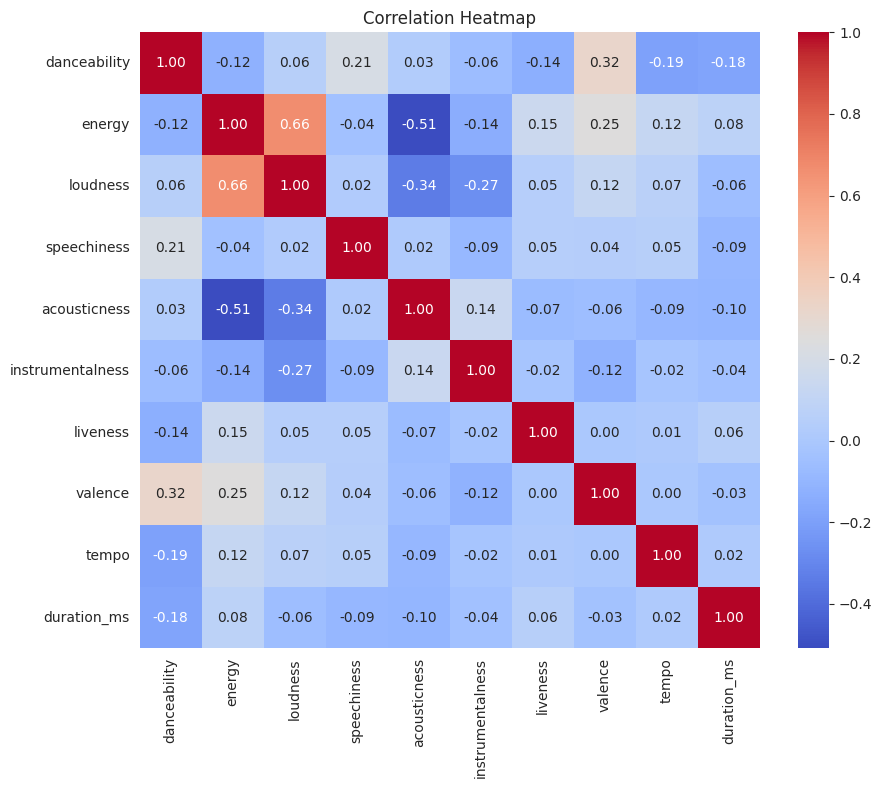

In [12]:
# Visualize the correlation between audio features
plt.figure(figsize=(10, 8))
sns.heatmap(
    spotify_cluster_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

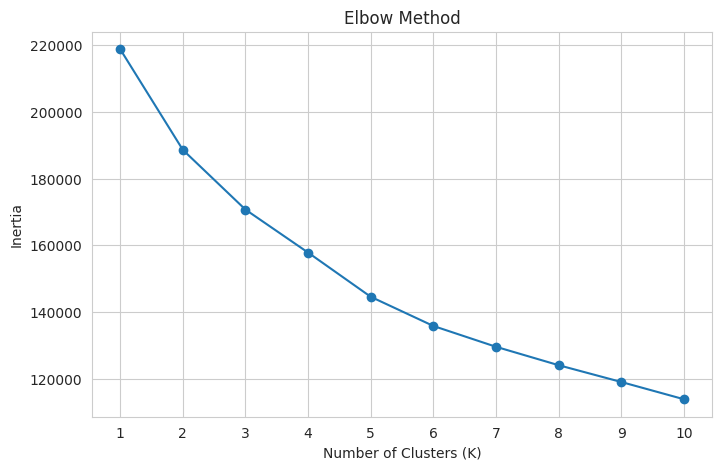

In [13]:
# Determine the optimal number of clusters using the Elbow Method
inertia_values = []
for no in range(1, 11):
    kmeans_model = KMeans(n_clusters=no, random_state=42, n_init=10)
    kmeans_model.fit(spotify_scaled)
    inertia_values.append(kmeans_model.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia_values, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

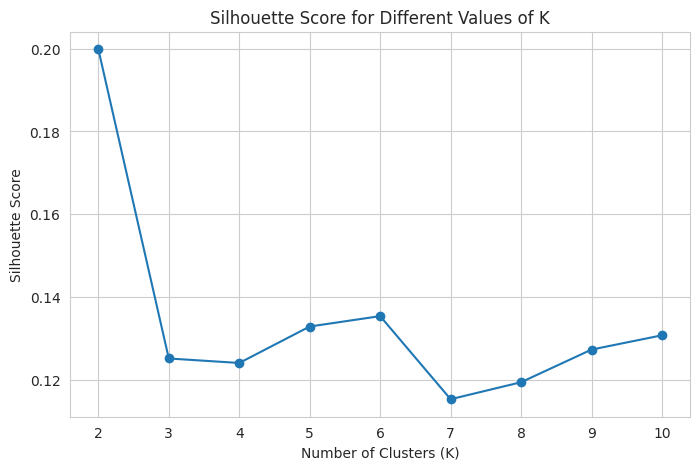

In [14]:
# Evaluate different values of K using the Silhouette Score
silhouette_scores = []
for no in range(2, 11):
    kmeans_model = KMeans(n_clusters=no, random_state=42, n_init=10)
    cluster_labels = kmeans_model.fit_predict(spotify_scaled)
    score = silhouette_score(spotify_scaled, cluster_labels)
    silhouette_scores.append(score)
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.title("Silhouette Score for Different Values of K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [15]:
# Train the final K-Means model using the selected number of clusters
kmeans_model = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans_model.fit_predict(spotify_scaled)

In [16]:
# Add the cluster labels to the original Spotify dataset
spotify_df["cluster"] = cluster_labels
spotify_df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,cluster
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-2.634,1.0,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754.0,2
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-4.969,1.0,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600.0,2
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-3.432,0.0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616.0,2
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-3.778,1.0,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093.0,0
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-4.672,1.0,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052.0,2


In [17]:
# Reduce the scaled data to two principal components for visualization
pca = PCA(n_components=2)
spotify_pca = pca.fit_transform(spotify_scaled)
spotify_pca = pd.DataFrame(
    spotify_pca,
    columns=["Principal Component 1", "Principal Component 2"]
)
spotify_pca["cluster"] = cluster_labels
spotify_pca.head()

,Principal Component 1,Principal Component 2,cluster
0,1.565574,0.572544,2
1,1.148164,0.705008,2
2,1.650726,0.481721,2
3,1.437697,0.033684,0
4,1.193456,0.431951,2


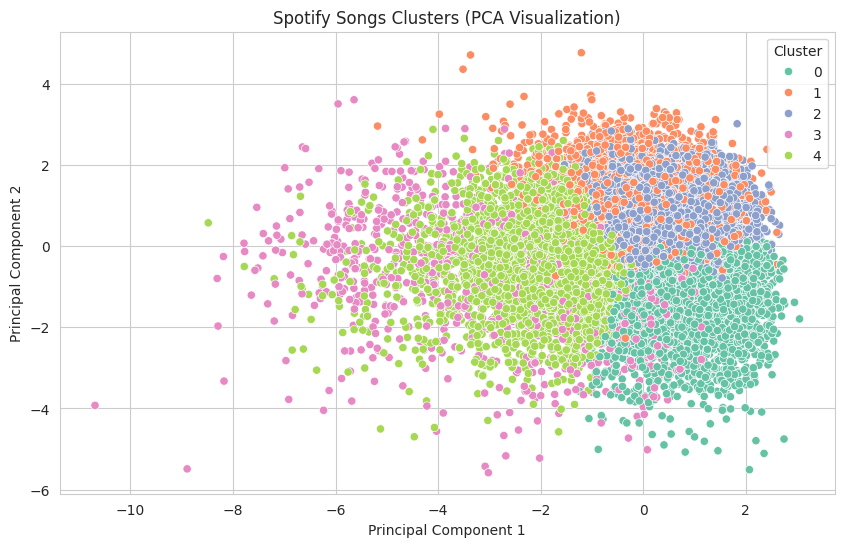

In [18]:
# Visualize the clusters using the first two principal components
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=spotify_pca,
    x="Principal Component 1",
    y="Principal Component 2",
    hue="cluster",
    palette="Set2"
)
plt.title("Spotify Songs Clusters (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

In [19]:
# Analyze the characteristics of each cluster using feature-wise averages
cluster_summary = spotify_df.groupby("cluster")[spotify_cluster_df.columns].mean()
display(cluster_summary)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
cluster,,,,,,,,,,
0,0.509671,0.808865,-5.588194,0.072597,0.062216,0.027370,0.256046,0.429324,133.147405,241123.165952
1,0.731035,0.668065,-6.734274,0.313882,0.173285,0.004962,0.201912,0.551063,123.027766,218207.859334
2,0.731075,0.746653,-5.720969,0.075744,0.139883,0.011652,0.153500,0.670333,115.706637,212917.326758
3,0.626801,0.583857,-9.910234,0.082475,0.305924,0.777090,0.169005,0.435966,118.057523,207324.797448
4,0.618191,0.474280,-9.930933,0.068001,0.410875,0.020991,0.155605,0.411076,115.118743,232313.635580


#  Business Insights

The clustering results can support several real-world **Spotify applications**, including:

- **Create personalized playlists** based on similar audio characteristics.
- **Improve music recommendation systems** by suggesting songs from the same cluster.

These clustering results can also be used to:

-  **Group songs** according to different moods and listening preferences.
-  **Design targeted playlists** for activities such as **workouts**, **studying**, **relaxation**, or **parties**.
-  **Enhance user engagement** through more relevant and personalized song recommendations.
-  **Support business decision-making** by helping Spotify better understand listener preferences and improve content discovery.

# Conclusion

In this project, the Spotify songs dataset was successfully clustered using the K-Means algorithm. The data was preprocessed, standardized, and explored through EDA. The Elbow Method and Silhouette Score were used to determine an appropriate number of clusters. After training the final model, PCA was applied to visualize the clusters in two dimensions.

Finally, the clusters were interpreted based on their average audio feature values, allowing meaningful song categories to be identified. The results demonstrate how unsupervised learning can uncover hidden patterns in music data and support applications such as playlist generation, recommendation systems, and user segmentation.

In [21]:
import joblib
joblib.dump(kmeans_model, "kmeans_model.pkl")

['kmeans_model.pkl']